   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 24.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 24.2 MB/s eta 0:00:00


Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/jangedoo/utkface-new
License(s): copyright-authors
 89% 296M/331M [00:00<00:00, 891MB/s] 
100% 331M/331M [00:00<00:00, 796MB/s]
Total samples: 23708
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
100%|██████████| 44.7M/44.7M [00:00<00:00, 173MB/s]


Epoch 1, Loss: 416.0999
Epoch 2, Loss: 61.7598
Epoch 3, Loss: 43.1811
Epoch 4, Loss: 29.6713
Epoch 5, Loss: 22.0563
Epoch 6, Loss: 16.7454
Epoch 7, Loss: 13.0560
Epoch 8, Loss: 11.0809
Epoch 9, Loss: 9.6880
Epoch 10, Loss: 8.5103
Combined model saved.


Saving 273271,1bc75000ad1a58db.jpg to 273271,1bc75000ad1a58db.jpg


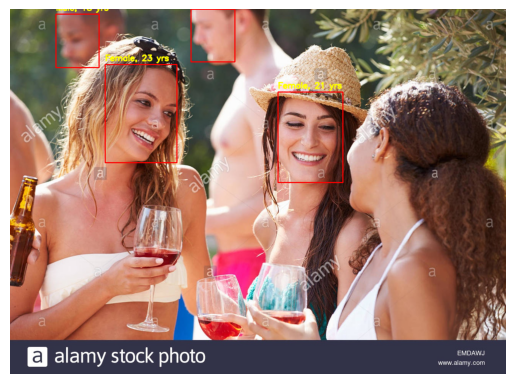

In [1]:
!pip install kaggle mtcnn
from google.colab import files
import os, shutil, random
import numpy as np
import cv2
from PIL import Image, ImageDraw, ImageFont
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from mtcnn import MTCNN

files.upload()   # upload kaggle.json
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download -d jangedoo/utkface-new
!unzip -q utkface-new.zip -d utkface_new

class UTKFaceDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.files = [f for f in os.listdir(root_dir) if f.endswith(".jpg")]
        self.transform = transform

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        img_name = self.files[idx]
        parts = img_name.split("_")
        age = int(parts[0])
        gender = int(parts[1])   # 0 = male, 1 = female

        img_path = os.path.join(self.root_dir, img_name)
        img = Image.open(img_path).convert("RGB")

        if self.transform:
            img = self.transform(img)

        return img, age, gender

transform = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.ToTensor(),
    transforms.Normalize([0.5,0.5,0.5],[0.5,0.5,0.5])
])

dataset = UTKFaceDataset("utkface_new/UTKFace", transform=transform)
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

print("Total samples:", len(dataset))

# ===========================
# MULTITASK RESNET18
# ===========================
class AgeGenderResNet(nn.Module):
    def __init__(self):
        super(AgeGenderResNet, self).__init__()
        self.base_model = models.resnet18(pretrained=True)
        in_features = self.base_model.fc.in_features
        self.base_model.fc = nn.Identity()  # remove final FC
        # Two heads
        self.age_head = nn.Linear(in_features, 1)    # regression
        self.gender_head = nn.Linear(in_features, 2) # classification

    def forward(self, x):
        features = self.base_model(x)
        age_out = self.age_head(features)
        gender_out = self.gender_head(features)
        return age_out, gender_out

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = AgeGenderResNet().to(device)

criterion_age = nn.MSELoss()
criterion_gender = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

for epoch in range(10):  # increase for better accuracy
    model.train()
    total_loss = 0
    for imgs, ages, genders in dataloader:
        imgs = imgs.to(device)
        ages = ages.float().unsqueeze(1).to(device)
        genders = genders.to(device)

        optimizer.zero_grad()
        age_pred, gender_pred = model(imgs)

        loss_age = criterion_age(age_pred, ages)
        loss_gender = criterion_gender(gender_pred, genders)
        loss = loss_age + loss_gender  # combine

        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss/len(dataloader):.4f}")

torch.save(model.state_dict(), "age_gender_model.pth")
print("Combined model saved.")

def predict_age_gender(img):
    img_tensor = transform(img).unsqueeze(0).to(device)
    model.eval()
    with torch.no_grad():
        age_pred, gender_pred = model(img_tensor)
        age = int(age_pred.item())
        gender = "Male" if torch.argmax(gender_pred,1).item()==0 else "Female"
    return age, gender

detector = MTCNN()

def pil_to_cv2(pil_img):
    return cv2.cvtColor(np.array(pil_img), cv2.COLOR_RGB2BGR)

def cv2_to_pil(cv2_img):
    return Image.fromarray(cv2.cvtColor(cv2_img, cv2.COLOR_BGR2RGB))

uploaded = files.upload()
for filename in uploaded.keys():
    img = Image.open(filename).convert("RGB")
    cv_img = pil_to_cv2(img)  # convert to OpenCV format

    faces = detector.detect_faces(np.array(img))
    for face in faces:
        x, y, w, h = face['box']
        if w < 50 or h < 50:
            continue
        face_crop = img.crop((x, y, x+w, y+h))
        age, gender = predict_age_gender(face_crop)

        cv2.rectangle(cv_img, (x, y), (x+w, y+h), (0, 0, 255), 2)

        text = f"{gender}, {age} yrs"
        cv2.putText(cv_img, text, (x, y-10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 255), 2, cv2.LINE_AA)

    img_draw = cv2_to_pil(cv_img)
    plt.imshow(img_draw)
    plt.axis("off")
    plt.show()

Saving 273271,1be0200037d3046d.jpg to 273271,1be0200037d3046d.jpg
Dataset URL: https://www.kaggle.com/datasets/jangedoo/utkface-new
License(s): copyright-authors
utkface-new.zip: Skipping, found more recently modified local copy (use --force to force download)
replace utkface_new/UTKFace/100_0_0_20170112213500903.jpg.chip.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
Dataset URL: https://www.kaggle.com/datasets/msambare/fer2013
License(s): DbCL-1.0
  0% 0.00/60.3M [00:00<?, ?B/s]
100% 60.3M/60.3M [00:00<00:00, 884MB/s]


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


Total samples: 52414
Emotion classes: {'angry': 0, 'disgust': 1, 'fear': 2, 'happy': 3, 'neutral': 4, 'sad': 5, 'surprise': 6}
Number of FER images: 28709


/tmp/ipython-input-802564875.py:128: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  ages, genders, ethnics, emotions = [torch.tensor(l).to(device) for l in (ages, genders, ethnics, emotions)]


Epoch 1, Loss: 158.1480
Epoch 2, Loss: 62.9173
Epoch 3, Loss: 52.2978
Epoch 4, Loss: 44.9034
Epoch 5, Loss: 38.6385
Epoch 6, Loss: 34.6066
Epoch 7, Loss: 31.6913
Epoch 8, Loss: 27.0038
Epoch 9, Loss: 24.9285
Epoch 10, Loss: 21.9334
Model saved


Saving 273271,1be0200037d3046d.jpg to 273271,1be0200037d3046d (1).jpg
Face 1:
   Gender    : Female
   Age       : 24
   Ethnicity : Black
   Emotion   : sad
   Saved at  : cropped_faces/273271,1be0200037d3046d (1)_face_1.jpg
--------------------------------------------------
Face 2:
   Gender    : Female
   Age       : 15
   Ethnicity : Black
   Emotion   : happy
   Saved at  : cropped_faces/273271,1be0200037d3046d (1)_face_2.jpg
--------------------------------------------------
Face 3:
   Gender    : Female
   Age       : 26
   Ethnicity : Black
   Emotion   : sad
   Saved at  : cropped_faces/273271,1be0200037d3046d (1)_face_3.jpg
--------------------------------------------------


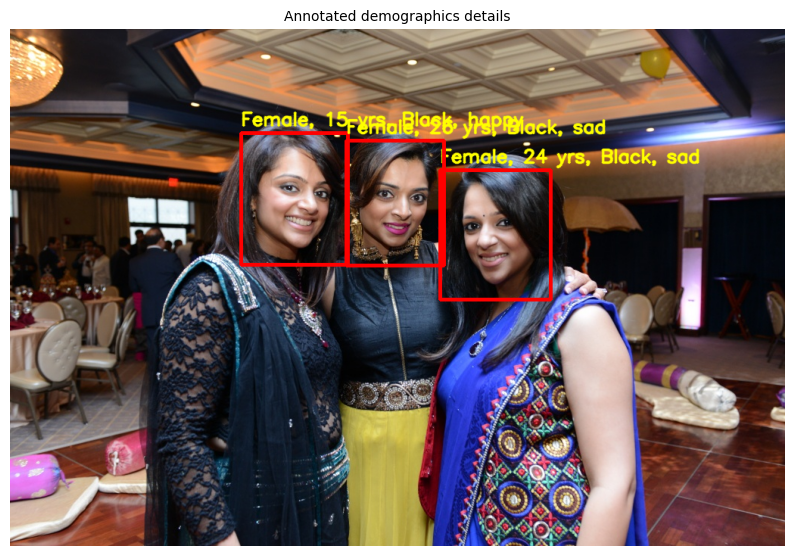

In [2]:
!pip install kaggle mtcnn
import os, cv2, torch
import numpy as np
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
import matplotlib.pyplot as plt
from google.colab import files
from mtcnn import MTCNN

files.upload()

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download -d jangedoo/utkface-new
!unzip -q utkface-new.zip -d utkface_new

!kaggle datasets download -d msambare/fer2013
!unzip -q fer2013.zip -d fer2013_data

def preprocess_image(img_path, size=(128,128)):
    img = Image.open(img_path).convert("RGB")
    img = img.resize(size)
    return img

class MultiTaskDataset(Dataset):
    def __init__(self, utk_dir, fer_dir, transform=None, preprocess=True):
        self.transform = transform
        self.utk_files = []
        for f in os.listdir(utk_dir):
            if f.endswith(".jpg"):
                parts = f.split("_")
                if len(parts) >= 4 and parts[0].isdigit() and parts[1].isdigit() and parts[2].isdigit():
                    self.utk_files.append(os.path.join(utk_dir, f))

        # ---- FER2013 (emotions) ----
        self.fer_files, self.fer_labels = [], []
        for label_name in os.listdir(fer_dir):
            label_dir = os.path.join(fer_dir, label_name)
            if os.path.isdir(label_dir):
                for img_file in os.listdir(label_dir):
                    if img_file.endswith((".jpg",".png")):
                        self.fer_files.append(os.path.join(label_dir,img_file))
                        self.fer_labels.append(label_name)
        if len(self.fer_labels) > 0:
            self.emotion_map = {name: idx for idx, name in enumerate(sorted(set(self.fer_labels)))}
        else:
            self.emotion_map = {}
        self.preprocess = preprocess

    def __len__(self):
        return len(self.utk_files) + len(self.fer_files)

    def __getitem__(self, idx):
        if idx < len(self.utk_files):
            # --- UTKFace ---
            img_path = self.utk_files[idx]
            parts = os.path.basename(img_path).split("_")
            age, gender, ethnicity = int(parts[0]), int(parts[1]), int(parts[2])
            emotion = -1
        else:
            # ---- FER2013 ----
            idx2 = idx - len(self.utk_files)
            img_path = self.fer_files[idx2]
            emotion_name = self.fer_labels[idx2]
            emotion = self.emotion_map[emotion_name]
            age, gender, ethnicity = -1, -1, -1

        img = preprocess_image(img_path) if self.preprocess else Image.open(img_path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, age, gender, ethnicity, emotion

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.RandomHorizontalFlip(),
    transforms.Normalize([0.5,0.5,0.5],[0.5,0.5,0.5])
])

dataset = MultiTaskDataset("utkface_new/UTKFace", "fer2013_data/train", transform=transform, preprocess=True)
dataloader = DataLoader(dataset, batch_size=32, shuffle=True, num_workers=4, pin_memory=True)
print("Total samples:", len(dataset))
print("Emotion classes:", dataset.emotion_map)
print("Number of FER images:", len(dataset.fer_files))

class MultiTaskResNet(nn.Module):
    def __init__(self, num_ethnicity=5, num_emotions=7):
        super().__init__()
        self.base_model = models.resnet18(pretrained=True)
        in_features = self.base_model.fc.in_features
        self.base_model.fc = nn.Identity()
        self.age_head = nn.Linear(in_features, 1)
        self.gender_head = nn.Linear(in_features, 2)
        self.ethnicity_head = nn.Linear(in_features, num_ethnicity)
        self.emotion_head = nn.Linear(in_features, num_emotions)

    def forward(self, x):
        features = self.base_model(x)
        return self.age_head(features), self.gender_head(features), \
               self.ethnicity_head(features), self.emotion_head(features)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = MultiTaskResNet().to(device)

criterion_age = nn.MSELoss()
criterion_gender = nn.CrossEntropyLoss()
num_white = sum(1 for f in dataset.utk_files if int(os.path.basename(f).split("_")[2]) == 0)
num_black = sum(1 for f in dataset.utk_files if int(os.path.basename(f).split("_")[2]) == 1)
num_asian = sum(1 for f in dataset.utk_files if int(os.path.basename(f).split("_")[2]) == 2)
num_indian = sum(1 for f in dataset.utk_files if int(os.path.basename(f).split("_")[2]) == 3)
num_other = sum(1 for f in dataset.utk_files if int(os.path.basename(f).split("_")[2]) == 4)

ethnicity_counts = [num_white, num_black, num_asian, num_indian, num_other]
weights = 1.0 / torch.tensor(ethnicity_counts, dtype=torch.float)
criterion_ethnicity = nn.CrossEntropyLoss(weight=weights.to(device))
criterion_emotion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

for epoch in range(10):
    model.train()
    total_loss = 0
    for imgs, ages, genders, ethnics, emotions in dataloader:
        imgs = imgs.to(device)
        ages, genders, ethnics, emotions = [torch.tensor(l).to(device) for l in (ages, genders, ethnics, emotions)]
        optimizer.zero_grad()
        age_pred, gender_pred, eth_pred, emo_pred = model(imgs)
        loss = 0
        if (ages>=0).any():
            mask = ages>=0
            loss += criterion_age(age_pred[mask], ages[mask].float().unsqueeze(1))
        if (genders>=0).any():
            mask = genders>=0
            loss += criterion_gender(gender_pred[mask], genders[mask])
        if (ethnics>=0).any():
            mask = ethnics>=0
            loss += criterion_ethnicity(eth_pred[mask], ethnics[mask])
        if (emotions>=0).any():
            mask = emotions>=0
            loss += criterion_emotion(emo_pred[mask], emotions[mask])
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1}, Loss: {total_loss/len(dataloader):.4f}")

torch.save(model.state_dict(), "multitask_model_fast.pth")
print("Model saved")

ethnicity_map = {0:"White",1:"Black",2:"Asian",3:"Indian",4:"Other"}
emotion_map = {v:k for k,v in dataset.emotion_map.items()}

def predict_all(face_img):
    model.eval()
    img_tensor = transform(face_img).unsqueeze(0).to(device)
    with torch.no_grad():
        age_pred, gender_pred, eth_pred, emo_pred = model(img_tensor)
        age = int(age_pred.item())
        gender = "Male" if torch.argmax(gender_pred,1).item()==0 else "Female"
        ethnicity = ethnicity_map[torch.argmax(eth_pred,1).item()]
        emotion = emotion_map[torch.argmax(emo_pred,1).item()]
    return age, gender, ethnicity, emotion

detector = MTCNN()

def pil_to_cv2(pil_img): return cv2.cvtColor(np.array(pil_img), cv2.COLOR_RGB2BGR)
def cv2_to_pil(cv2_img): return Image.fromarray(cv2.cvtColor(cv2_img, cv2.COLOR_BGR2RGB))

uploaded = files.upload()
os.makedirs("cropped_faces", exist_ok=True)

for filename in uploaded.keys():
    img = Image.open(filename).convert("RGB")
    cv_img = pil_to_cv2(img)
    faces = detector.detect_faces(np.array(img))
    for idx, face in enumerate(faces):
        x,y,w,h = face['box']
        if w<50 or h<50: continue
        pad = int(0.3 * w)
        x1 = max(0, x - pad)
        y1 = max(0, y - pad)
        x2 = min(img.width, x + w + pad)
        y2 = min(img.height, y + h + pad)

        face_crop = img.crop((x1, y1, x2, y2))
        age, gender, ethnicity, emotion = predict_all(face_crop)
        cv2.rectangle(cv_img, (x1, y1), (x2, y2), (0,0,255), 3)
        text = f"{gender}, {age} yrs, {ethnicity}, {emotion}"
        cv2.putText(cv_img, text,(x1,max(y1-10,0)),cv2.FONT_HERSHEY_SIMPLEX,0.8,(0,255,255),2, cv2.LINE_AA)

        face_filename = f"cropped_faces/{os.path.splitext(filename)[0]}_face_{idx+1}.jpg"
        face_crop.save(face_filename)

        # ---- print demographics ----
        print(f"Face {idx+1}:")
        print(f"   Gender    : {gender}")
        print(f"   Age       : {age}")
        print(f"   Ethnicity : {ethnicity}")
        print(f"   Emotion   : {emotion}")
        print(f"   Saved at  : {face_filename}")
        print("-"*50)

    plt.figure(figsize=(10,10))
    plt.imshow(cv2_to_pil(cv_img))
    plt.axis("off")
    plt.title(f"Annotated demographics details", fontsize=10)
    plt.show()

Evaluation Results:
Age {'MAE': 3.022928476333618, 'RMSE': np.float64(4.114364553823919)}
Gender {'Accuracy': 0.9180121618788006, 'F1': 0.9137436576218839}
Ethnicity {'Accuracy': 0.7580205493814217, 'F1': 0.7064471891836328}
Emotion {'Accuracy': 0.5913545677283865, 'F1': 0.49193389181049524}


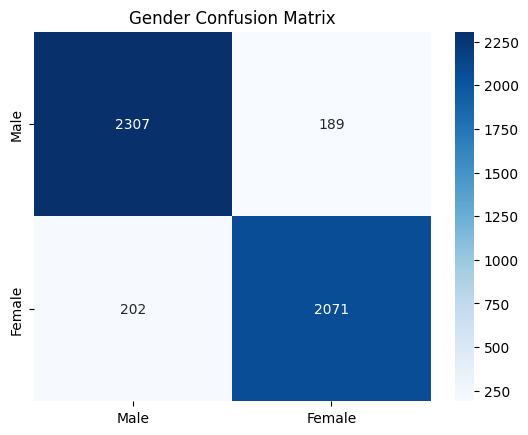

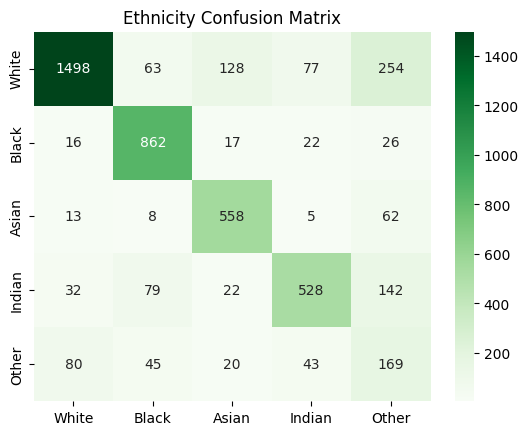

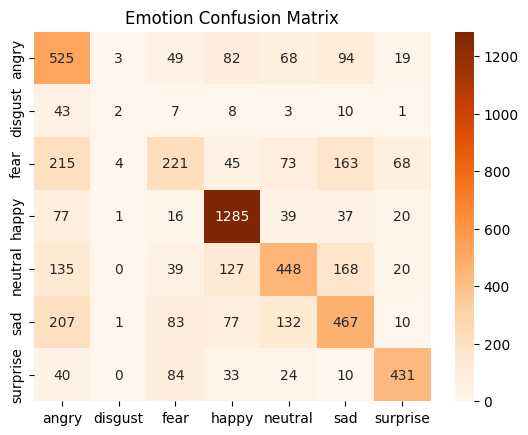

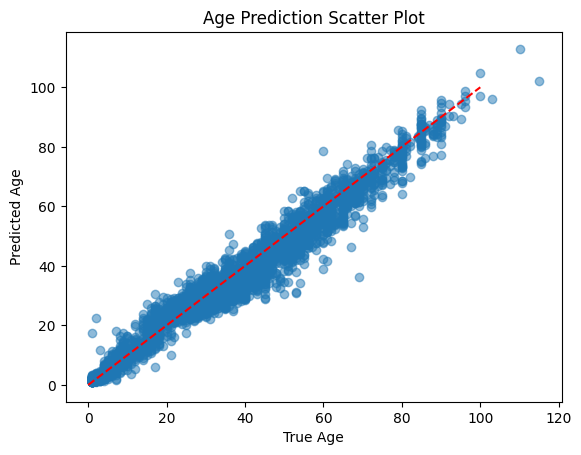

In [3]:
import torch
from torch.utils.data import DataLoader, random_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, mean_absolute_error, mean_squared_error
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# ---- Evaluation Function ----
def evaluate(model, dataloader, device):
    model.eval()
    all_ages, all_age_preds = [], []
    all_genders, all_gender_preds = [], []
    all_eth, all_eth_preds = [], []
    all_emo, all_emo_preds = [], []

    with torch.no_grad():
        for imgs, ages, genders, ethnics, emotions in dataloader:
            imgs = imgs.to(device)
            ages, genders, ethnics, emotions = (
                ages.to(device), genders.to(device),
                ethnics.to(device), emotions.to(device)
            )

            age_pred, gender_pred, eth_pred, emo_pred = model(imgs)

            # --- Age ---
            mask = ages >= 0
            if mask.any():
                all_ages.extend(ages[mask].cpu().numpy())
                all_age_preds.extend(age_pred[mask].cpu().numpy())

            # --- Gender ---
            mask = genders >= 0
            if mask.any():
                all_genders.extend(genders[mask].cpu().numpy())
                all_gender_preds.extend(torch.argmax(gender_pred[mask], 1).cpu().numpy())

            # --- Ethnicity ---
            mask = ethnics >= 0
            if mask.any():
                all_eth.extend(ethnics[mask].cpu().numpy())
                all_eth_preds.extend(torch.argmax(eth_pred[mask], 1).cpu().numpy())

            # --- Emotion ---
            mask = emotions >= 0
            if mask.any():
                all_emo.extend(emotions[mask].cpu().numpy())
                all_emo_preds.extend(torch.argmax(emo_pred[mask], 1).cpu().numpy())

    # --- Metrics ---
    results = {}
    if len(all_ages) > 0:
        mae = mean_absolute_error(all_ages, np.array(all_age_preds).flatten())
        rmse = np.sqrt(mean_squared_error(all_ages, np.array(all_age_preds).flatten()))
        results["Age"] = {"MAE": mae, "RMSE": rmse}

    if len(all_genders) > 0:
        acc = accuracy_score(all_genders, all_gender_preds)
        f1 = f1_score(all_genders, all_gender_preds, average="binary")
        results["Gender"] = {"Accuracy": acc, "F1": f1}

    if len(all_eth) > 0:
        acc = accuracy_score(all_eth, all_eth_preds)
        f1 = f1_score(all_eth, all_eth_preds, average="macro")
        results["Ethnicity"] = {"Accuracy": acc, "F1": f1}

    if len(all_emo) > 0:
        acc = accuracy_score(all_emo, all_emo_preds)
        f1 = f1_score(all_emo, all_emo_preds, average="macro")
        results["Emotion"] = {"Accuracy": acc, "F1": f1}

    return results, (all_ages, all_age_preds,
                     all_genders, all_gender_preds,
                     all_eth, all_eth_preds,
                     all_emo, all_emo_preds)


# ---- Train/Validation Split ----
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False)

# ---- Run Evaluation ----
results, preds = evaluate(model, val_loader, device)

print("Evaluation Results:")
for task, metrics in results.items():
    print(task, metrics)

# ---- Unpack predictions ----
all_ages, all_age_preds, g_true, g_pred, e_true, e_pred, emo_true, emo_pred = preds

# ---- Gender Confusion Matrix ----
cm = confusion_matrix(g_true, g_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Male","Female"], yticklabels=["Male","Female"])
plt.title("Gender Confusion Matrix")
plt.show()
print("\n\n")

# ---- Ethnicity Confusion Matrix ----
cm = confusion_matrix(e_true, e_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens",
            xticklabels=list(ethnicity_map.values()),
            yticklabels=list(ethnicity_map.values()))
plt.title("Ethnicity Confusion Matrix")
plt.show()
print("\n\n")

# ---- Emotion Confusion Matrix ----
cm = confusion_matrix(emo_true, emo_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Oranges",
            xticklabels=list(emotion_map.values()),
            yticklabels=list(emotion_map.values()))
plt.title("Emotion Confusion Matrix")
plt.show()
print("\n\n")

# ---- Age Regression Scatter ----
if len(all_ages) > 0:
    plt.scatter(all_ages, np.array(all_age_preds).flatten(), alpha=0.5)
    plt.xlabel("True Age")
    plt.ylabel("Predicted Age")
    plt.title("Age Prediction Scatter Plot")
    plt.plot([0,100],[0,100],"r--")
    plt.show()